<a href="https://colab.research.google.com/github/RishankSoni/es335-assignment-3/blob/main/ML_Assignment3_Task2_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_auc_score, accuracy_score
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression

In [46]:
np.random.seed(1337)

def make_moons_custom(n_samples=500, noise=0.2):
    """Generate a make_moons-like dataset with given noise."""
    n_samples_out = n_samples // 2
    n_samples_in = n_samples - n_samples_out # 250 samples each

    theta_outer = np.linspace(0, np.pi, n_samples_out)
    x_outer = np.stack([np.cos(theta_outer), np.sin(theta_outer)], axis=1)

    theta_inner = np.linspace(0, np.pi, n_samples_in)
    x_inner = np.stack([1 - np.cos(theta_inner), 1 - np.sin(theta_inner) - 0.5], axis=1) # (cosx, sinx) and ((1-cosx),(1-sinx-0.5)) over interval [0, pi]

    X = np.vstack([x_outer, x_inner])
    y = np.hstack([np.zeros(n_samples_out), np.ones(n_samples_in)]) # binary classification

    X += noise * np.random.randn(*X.shape)
    return X, y

def standardize_train_test(X_train, X_test):
    """Standardize using train statistics."""
    mean = X_train.mean(axis=0) # standardizing using train statistics only
    std = X_train.std(axis=0)
    X_train_std = (X_train - mean) / std
    X_test_std = (X_test - mean) / std
    return X_train_std, X_test_std

def split_train_val(X, y, val_ratio=0.2):
    """Split into training and validation sets."""
    n_total = X.shape[0]
    n_val = int(n_total * val_ratio)
    indices = np.random.permutation(n_total) # randomly selecting 20 % of total samples for validation set
    val_idx, train_idx = indices[:n_val], indices[n_val:]
    return X[train_idx], y[train_idx], X[val_idx], y[val_idx]

In [47]:
X_train_02, y_train_02 = make_moons_custom(500, noise=0.2)
X_test_02, y_test_02 = make_moons_custom(500, noise=0.2)

X_train_02_std, X_test_02_std = standardize_train_test(X_train_02, X_test_02)

X_train_main, y_train_main, X_val_main, y_val_main = split_train_val(X_train_02_std, y_train_02)

X_test_01, y_test_01 = make_moons_custom(500, noise=0.1) # extra test sets with noise 0.1 and 0.3
X_test_03, y_test_03 = make_moons_custom(500, noise=0.3)

X_test_01_std = (X_test_01 - X_train_02.mean(axis=0)) / X_train_02.std(axis=0) # standardizing them, again using train statistics only
X_test_03_std = (X_test_03 - X_train_02.mean(axis=0)) / X_train_02.std(axis=0)

print("Train:", X_train_main.shape, "Val:", X_val_main.shape, "Test:", X_test_02_std.shape)

Train: (400, 2) Val: (100, 2) Test: (500, 2)


In [48]:
# Model 1: MLP with hidden layer

# noise = 0.2

mlp_es = MLPClassifier(
    hidden_layer_sizes=(50,25), # two hidden layers with 50 neurons in the first and 25 in the next
    activation='relu',          # using relu over sigmoid or tanh to avoid vanishing gradients, stable training, nonlinearity, and sparse activations
    solver='adam',
    early_stopping=True,        # early stopping
    n_iter_no_change=50,        # patience = 50, if validation score doesn't improve after 50 epochs, then stop training
    validation_fraction=0.2,    # internal validation dataset for tracking validation performance
    random_state=1337,
    max_iter=2000
)

mlp_es.fit(X_train_02_std, y_train_02)

acc_02_m1 = accuracy_score(y_test_02, mlp_es.predict(X_test_02_std))

acc_01_m1 = accuracy_score(y_test_01, mlp_es.predict(X_test_01_std))

acc_03_m1 = accuracy_score(y_test_03, mlp_es.predict(X_test_03_std))

para_m1 = sum(w.size for w in mlp_es.coefs_) + sum(b.size for b in mlp_es.intercepts_)

In [49]:
# Model 2: MLP with L1 regularization

seed = 1337
np.random.seed(seed)
torch.manual_seed(seed) # PyTorch needed for L1 regularization because sklearn's MLPClassifier has only L2 regularization

lambdas = [1e-6, 3e-6, 1e-5, 3e-5, 1e-4, 3e-4]
n_epochs = 1000
batch_size = 64 # number of samples before updating weight
lr = 1e-3 # step size for gradient descent
hidden_dim = 50
device = torch.device("cpu")

def to_tensor(x, dtype=torch.float32): # all numpy arrays to be converted to tensors for PyTorch
    return torch.from_numpy(x.astype(np.float32)).to(device)

X_tr = to_tensor(X_train_main)
y_tr = torch.from_numpy(y_train_main.astype(np.int64)).to(device)

X_val = to_tensor(X_val_main)
y_val = torch.from_numpy(y_val_main.astype(np.int64)).to(device)

X_test02 = to_tensor(X_test_02_std)
y_test02 = torch.from_numpy(y_test_02.astype(np.int64)).to(device)

X_test01 = to_tensor(X_test_01_std)
y_test01 = torch.from_numpy(y_test_01.astype(np.int64)).to(device)

X_test03 = to_tensor(X_test_03_std)
y_test03 = torch.from_numpy(y_test_03.astype(np.int64)).to(device)

X_train_full = to_tensor(X_train_02_std)
y_train_full = torch.from_numpy(y_train_02.astype(np.int64)).to(device)

class SimpleMLP(nn.Module):
    def __init__(self, in_dim=2, hidden1=50, hidden2=25):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hidden1) # input and hidden layer 1 with 50 neurons
        self.fc2 = nn.Linear(hidden1, hidden2) # hidden layers 1 and 2 with 50 and 25 neurons respectively
        self.fc3 = nn.Linear(hidden2, 1) # hidden layer 2 and output
        self.act = nn.ReLU() # relu activation
    def forward(self, x): # forward pass
        x = self.act(self.fc1(x))
        x = self.act(self.fc2(x))
        x = self.fc3(x)
        return x # logit output for binary classification

def l1_penalty(model): # L1 regularization
    l1 = torch.tensor(0.0, device=device) # initializing L1
    for name, p in model.named_parameters(): # looping over model parameters
        if 'weight' in name:
            l1 = l1 + torch.sum(torch.abs(p)) # L1 norm of weights
    return l1

def layerwise_sparsity(model, threshold=1e-6): # no. of weights close to 0 (thus absolute value can be checked) / total no. of weights
    spars = [] # if threshold is kept too high, more number of weights would result in close to 0, increasing sparsity
    for name, p in model.named_parameters(): # if it is too low, sparsity is lesser
        if 'weight' in name:
            vals = p.detach().cpu().numpy()
            spars.append(np.mean(np.abs(vals) < threshold)) # for one layer, take the average of absolute values of weights less than threshold and add to list spars
    return spars

def train_model_with_l1(lambda_l1): # training loop for a single lambda
    model = SimpleMLP(in_dim=2).to(device)
    opt = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss() # binary cross entropy loss with logits

    best_val_auc = -np.inf # best validation AUROC
    best_state = None # weights corresponding to best validation AUROC

    n_train = X_tr.shape[0]
    n_batches = int(np.ceil(n_train / batch_size))

    for epoch in range(n_epochs):
        perm = np.random.permutation(n_train) # randomizing data every epoch
        model.train()
        for b in range(n_batches):
            idx = perm[b*batch_size:(b+1)*batch_size]
            xb = X_tr[idx]
            yb = y_tr[idx]

            logits = model(xb) # forward pass to find binary cross entropy loss
            loss = criterion(logits, yb.view(-1, 1).float())

            l1 = l1_penalty(model) # L1 regularization penalty
            loss = loss + lambda_l1 * l1

            opt.zero_grad() # back propagation and weight update
            loss.backward()
            opt.step()

        model.eval() # for validation AUROC without affecting the gradients
        with torch.no_grad():
            logits_val = model(X_val)
            probs_val = torch.sigmoid(logits_val).cpu().numpy().ravel()
        val_auc = roc_auc_score(y_val.cpu().numpy(), probs_val)

        if val_auc > best_val_auc: # storing those model parameters that give the best AUROC
            best_val_auc = val_auc
            best_state = {k:v.cpu().clone() for k,v in model.state_dict().items()}

    model.load_state_dict(best_state)
    return model, best_val_auc

models = [] # for trained models
val_aucs = [] # their AUROCs
sparsities = [] # and layer wise sparsities

for lam in lambdas: # training for each value of lambda
    print(f"Training λ = {lam} ...")
    model, val_auc = train_model_with_l1(lam)
    models.append(model)
    val_aucs.append(val_auc)
    sparsities.append(layerwise_sparsity(model, threshold=1e-4))
    print(f"  val AUROC = {val_auc:.4f}, layerwise sparsity = {sparsities[-1]}")

best_idx = int(np.argmax(val_aucs)) # finding the lambda that gives the highest AUROC and the corresponding model
best_lambda = lambdas[best_idx]
best_model = models[best_idx]
print(f"\nBest λ = {best_lambda}, val AUROC = {val_aucs[best_idx]:.4f}")

def predict_probs(model, X): # for predictions, using the best model and the test sets with noise 0.2, 0.1 and 0.3
    model.eval() # X is the tensor of the standardized test sets, the unscaled ones may lead to incorrect predictions
    with torch.no_grad():
        logits = model(X)
        probs = torch.sigmoid(logits).cpu().numpy()
    return probs # sigmoid probabilities from logits

yhat02 = (predict_probs(best_model, X_test02) >= 0.5).astype(int)
acc_02_m2 = accuracy_score(y_test02.cpu().numpy(), yhat02)

yhat01 = (predict_probs(best_model, X_test01) >= 0.5).astype(int)
acc_01_m2 = accuracy_score(y_test01.cpu().numpy(), yhat01)

yhat03 = (predict_probs(best_model, X_test03) >= 0.5).astype(int)
acc_03_m2 = accuracy_score(y_test03.cpu().numpy(), yhat03)

para_m2 = sum(p.numel() for p in best_model.parameters() if p.requires_grad)

for lam, s in zip(lambdas, sparsities):
    print(f"λ={lam:.0e} -> layer sparsity (fraction zeros): {s}")

Training λ = 1e-06 ...
  val AUROC = 0.9924, layerwise sparsity = [np.float64(0.01), np.float64(0.0824), np.float64(0.0)]
Training λ = 3e-06 ...
  val AUROC = 0.9940, layerwise sparsity = [np.float64(0.07), np.float64(0.14), np.float64(0.04)]
Training λ = 1e-05 ...
  val AUROC = 0.9936, layerwise sparsity = [np.float64(0.0), np.float64(0.1416), np.float64(0.04)]
Training λ = 3e-05 ...
  val AUROC = 0.9952, layerwise sparsity = [np.float64(0.01), np.float64(0.0112), np.float64(0.0)]
Training λ = 0.0001 ...
  val AUROC = 0.9952, layerwise sparsity = [np.float64(0.03), np.float64(0.068), np.float64(0.04)]
Training λ = 0.0003 ...
  val AUROC = 0.9952, layerwise sparsity = [np.float64(0.05), np.float64(0.184), np.float64(0.12)]

Best λ = 3e-05, val AUROC = 0.9952
λ=1e-06 -> layer sparsity (fraction zeros): [np.float64(0.01), np.float64(0.0824), np.float64(0.0)]
λ=3e-06 -> layer sparsity (fraction zeros): [np.float64(0.07), np.float64(0.14), np.float64(0.04)]
λ=1e-05 -> layer sparsity (fract

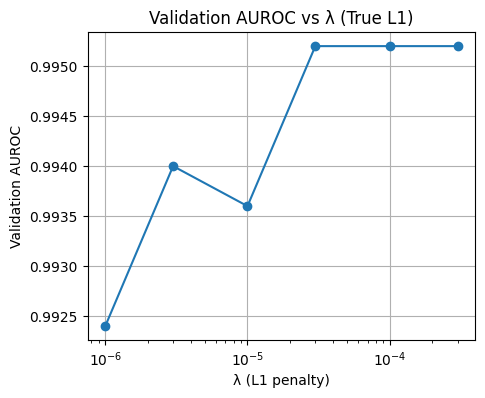

In [50]:
# validation AUROC vs lambda
plt.figure(figsize=(5,4))
plt.plot(lambdas, val_aucs, marker='o')
plt.xscale('log')
plt.xlabel('λ (L1 penalty)')
plt.ylabel('Validation AUROC')
plt.title('Validation AUROC vs λ (True L1)')
plt.grid(True)
plt.show()

In [51]:
np.random.seed(1337)
torch.manual_seed(1337)

class0_idx = np.where(y_train_02 == 0)[0]
class1_idx = np.where(y_train_02 == 1)[0]

n0 = int(0.7 * len(y_train_02)) # imbalance of 70:30 split, same training and testing, AUROC is same but accuracy is lesser
n1 = len(y_train_02) - n0
selected_idx = np.concatenate([
    np.random.choice(class0_idx, int(0.7 * n0), replace=False),
    np.random.choice(class1_idx, int(0.3 * n1), replace=False)
])
X_train_imb, y_train_imb = X_train_02[selected_idx], y_train_02[selected_idx]

scaler = StandardScaler().fit(X_train_imb)
X_train_imb_std = scaler.transform(X_train_imb)
X_test_02_std = scaler.transform(X_test_02)

X_train_t = torch.tensor(X_train_imb_std, dtype=torch.float32)
y_train_t = torch.tensor(y_train_imb.reshape(-1, 1), dtype=torch.float32)
X_test_t = torch.tensor(X_test_02_std, dtype=torch.float32)
y_test_t = torch.tensor(y_test_02.reshape(-1, 1), dtype=torch.float32)

class L1MLP(nn.Module):
    def __init__(self, in_dim=2, hidden1=50, hidden2=25):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.fc3 = nn.Linear(hidden2, 1)
        self.act = nn.ReLU()
    def forward(self, x):
        x = self.act(self.fc1(x))
        x = self.act(self.fc2(x))
        x = self.fc3(x)
        return x

model = L1MLP(in_dim=2).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

lambda_l1 = best_lambda
for epoch in range(1000):
    optimizer.zero_grad()
    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)

    l1_penalty = sum(torch.abs(p).sum() for p in model.parameters())
    loss += lambda_l1 * l1_penalty

    loss.backward()
    optimizer.step()

with torch.no_grad():
    y_pred = model(X_test_t).numpy().flatten()
    y_pred_cls = (y_pred > 0.5).astype(int)

acc_imb = accuracy_score(y_test_02, y_pred_cls)
auc_imb = roc_auc_score(y_test_02, y_pred)

print(f"Test Accuracy (imbalanced train): {acc_imb:.3f}")
print(f"AUROC (imbalanced train): {auc_imb:.3f}")

Test Accuracy (imbalanced train): 0.940
AUROC (imbalanced train): 0.995


AUROC is a representation of how well a model can identify the two different classes, and that is dependent on the classification, irrespective of any threshold, and is thus almost similar in both models.

However, the class imbalance would cause it to predict the majority class more than the minority. Increase in sparsity due to L1 regularization may cause loss of important features required for the smaller class detection, and thus could lead to a decline in accuracy as compared to the previous model.

In [52]:
# Model 3: MLP with L2 regularization

alphas = [0.0001, 0.001, 0.01, 0.1, 1]
best_acc = 0
best_alpha = None
best_model3 = None

for alpha in alphas: # here, L2 regularization can be used because MLPClassifier supports it with alpha parameter
    mlp = MLPClassifier(hidden_layer_sizes=(50,25),
                        activation='relu',
                        solver='adam',
                        alpha=alpha,
                        random_state=1337,
                        max_iter=2000)
    mlp.fit(X_train_main, y_train_main)
    val_acc = accuracy_score(y_val_main, mlp.predict(X_val_main))
    if val_acc > best_acc:
        best_acc = val_acc
        best_alpha = alpha
        best_model3 = mlp

print(f"Best alpha (L2 penalty): {best_alpha:.4f}, Validation accuracy: {best_acc:.4f}")

acc_02_m3 = accuracy_score(y_test_02, best_model3.predict(X_test_02_std))
acc_01_m3 = accuracy_score(y_test_01, best_model3.predict(X_test_01_std))
acc_03_m3 = accuracy_score(y_test_03, best_model3.predict(X_test_03_std))
para_m3 = sum(coef.size for coef in best_model3.coefs_) + sum(inter.size for inter in best_model3.intercepts_)

Best alpha (L2 penalty): 0.0001, Validation accuracy: 0.9800


In [53]:
# Model 4: Logistic Regression

poly = PolynomialFeatures(degree=2, include_bias=False) # polynomial features upto degree 2

X_train_poly = poly.fit_transform(X_train_02_std)
X_val_poly = poly.transform(X_val_main)
X_test_poly = poly.transform(X_test_02_std)
X_test01_poly = poly.transform(X_test_01_std)
X_test03_poly = poly.transform(X_test_03_std)

logreg = LogisticRegression(max_iter=2000, random_state=1337)
logreg.fit(X_train_poly, y_train_02) # training

y_test_pred = logreg.predict(X_test_poly)
y_test01_pred = logreg.predict(X_test01_poly)
y_test03_pred = logreg.predict(X_test03_poly)

acc_02_m4 = accuracy_score(y_test_02, y_test_pred)
acc_01_m4 = accuracy_score(y_test_01, y_test01_pred)
acc_03_m4 = accuracy_score(y_test_03, y_test03_pred)
para_m4 = sum(coef.size for coef in logreg.coef_) + logreg.intercept_.size

In [54]:
data = {
    "Model": [
        "MLP (Early Stopping)",
        "MLP (L1 Regularization)",
        "MLP (L2 Regularization)",
        "Logistic Regression"
    ],
    "Params": [
        para_m1,
        para_m2,
        para_m3,
        para_m4
    ],
    "Acc (Noise=0.2)": [
        acc_02_m1,
        acc_02_m2,
        acc_02_m3,
        acc_02_m4
    ],
    "Acc (Noise=0.1)": [
        acc_01_m1,
        acc_01_m2,
        acc_01_m3,
        acc_01_m4
    ],
    "Acc (Noise=0.3)": [
        acc_03_m1,
        acc_03_m2,
        acc_03_m3,
        acc_03_m4
    ]
}

results_df = pd.DataFrame(data)

results_df[["Acc (Noise=0.2)", "Acc (Noise=0.1)", "Acc (Noise=0.3)"]] = results_df[
    ["Acc (Noise=0.2)", "Acc (Noise=0.1)", "Acc (Noise=0.3)"]
].round(3)

print(results_df.to_string(index=False))

                  Model  Params  Acc (Noise=0.2)  Acc (Noise=0.1)  Acc (Noise=0.3)
   MLP (Early Stopping)    1451            0.918            0.942            0.878
MLP (L1 Regularization)    1451            0.974            0.998            0.912
MLP (L2 Regularization)    1451            0.852            0.998            0.910
    Logistic Regression       6            0.846            0.876            0.842


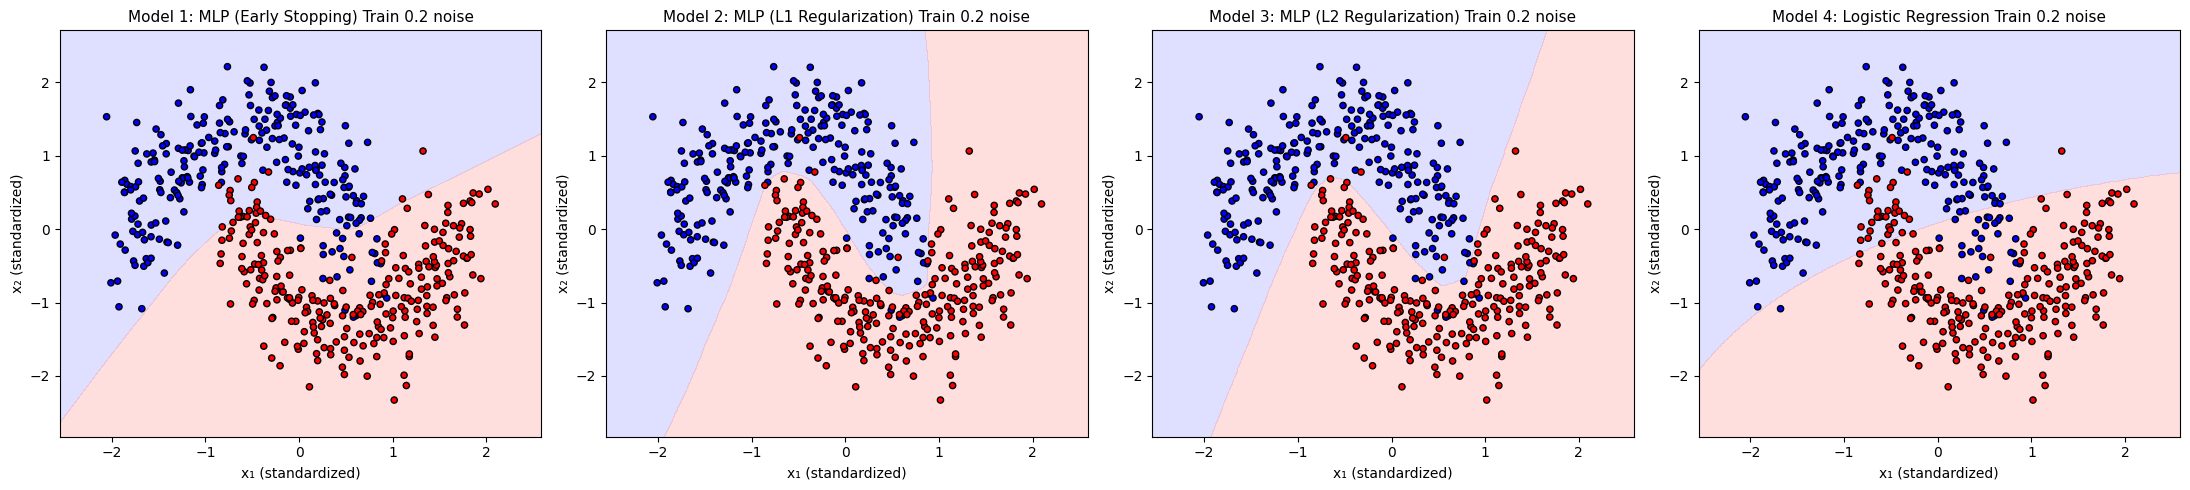

In [55]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

x_min, x_max = X_train_02_std[:, 0].min() - 0.5, X_train_02_std[:, 0].max() + 0.5
y_min, y_max = X_train_02_std[:, 1].min() - 0.5, X_train_02_std[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))
grid = np.c_[xx.ravel(), yy.ravel()]

# --- Model 1 predictions ---
Z1 = mlp_es.predict_proba(grid)[:, 1].reshape(xx.shape)

# --- Model 2 predictions (PyTorch L1 MLP) ---
probs2 = predict_probs(best_model, torch.from_numpy(grid.astype(np.float32)).to(device))
Z2 = (probs2 >= 0.5).astype(int).reshape(xx.shape)

# --- Model 3 predictions (L2 MLP) ---
Z3 = mlp.predict(grid).reshape(xx.shape)

# --- Model 4 predictions (Logistic Regression with polynomial features) ---
Z4 = logreg.predict(poly.transform(grid)).reshape(xx.shape)

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
titles = [
    "Model 1: MLP (Early Stopping) Train 0.2 noise",
    "Model 2: MLP (L1 Regularization) Train 0.2 noise",
    "Model 3: MLP (L2 Regularization) Train 0.2 noise",
    "Model 4: Logistic Regression Train 0.2 noise"
]

Z_list = [Z1, Z2, Z3, Z4]
for ax, Z, title in zip(axes, Z_list, titles):
    ax.contourf(xx, yy, Z, levels=[0, 0.5, 1], cmap='bwr', alpha=0.25)
    ax.scatter(X_train_02_std[:, 0], X_train_02_std[:, 1],
               c=y_train_02, cmap='bwr', edgecolor='k', s=20)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("x₁ (standardized)")
    ax.set_ylabel("x₂ (standardized)")

plt.tight_layout()
plt.show()

L1 regularization: The L1 penalty increases sparsity by drawing smaller weights close to zero, thus unncessary neurons are almost discarded. As a result accuracy is more, but, since sparsity increased, and lesser neurons contribute to the model now, the boundary is less smooth and more jagged.

L2 regularization: All weights are present, small but non-zero, and all neurons remain active. Thus, the boundary is smoother and the margin wider.

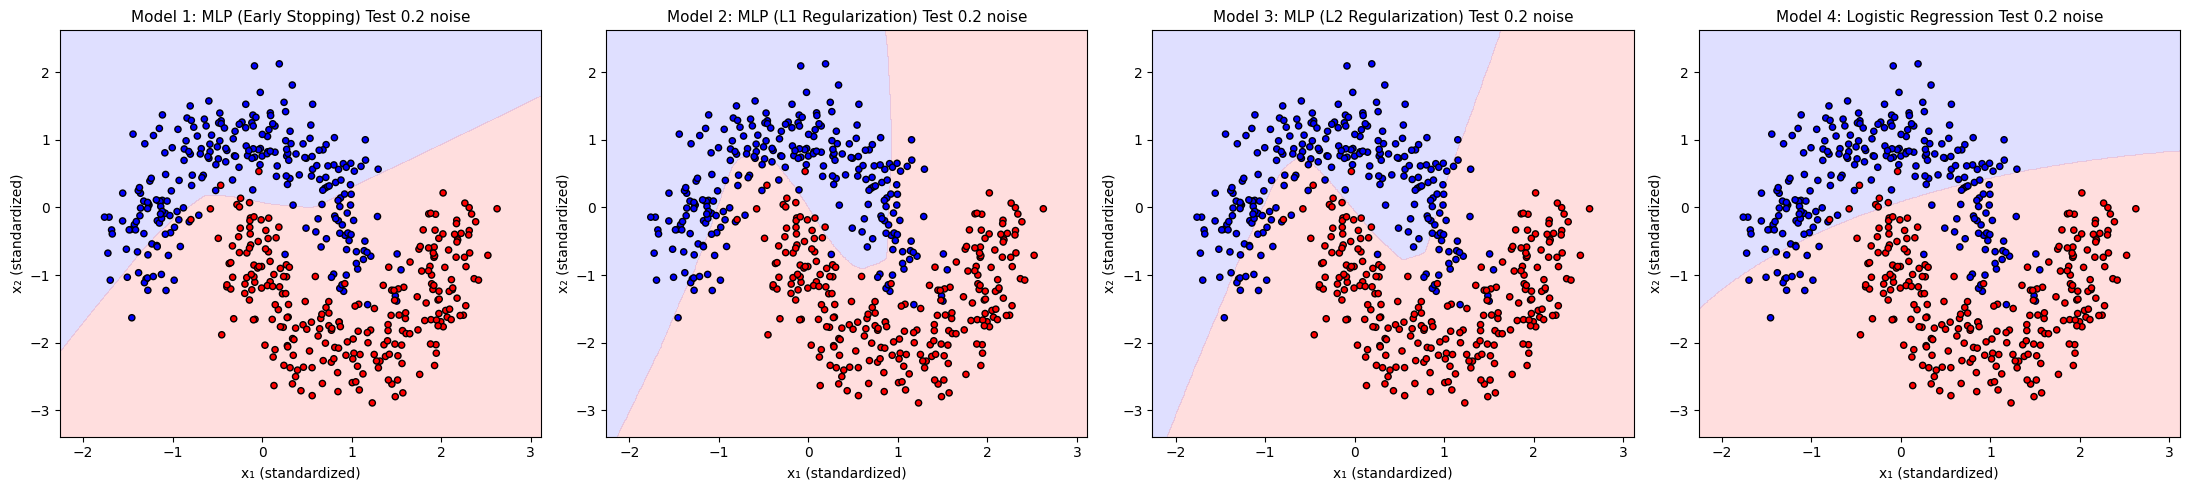

In [56]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

x_min, x_max = X_test_02_std[:, 0].min() - 0.5, X_test_02_std[:, 0].max() + 0.5
y_min, y_max = X_test_02_std[:, 1].min() - 0.5, X_test_02_std[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))
grid = np.c_[xx.ravel(), yy.ravel()]

# --- Model 1 predictions ---
Z1 = mlp_es.predict_proba(grid)[:, 1].reshape(xx.shape)

# --- Model 2 predictions (PyTorch L1 MLP) ---
probs2 = predict_probs(best_model, torch.from_numpy(grid.astype(np.float32)).to(device))
Z2 = (probs2 >= 0.5).astype(int).reshape(xx.shape)

# --- Model 3 predictions (L2 MLP) ---
Z3 = mlp.predict(grid).reshape(xx.shape)

# --- Model 4 predictions (Logistic Regression with polynomial features) ---
Z4 = logreg.predict(poly.transform(grid)).reshape(xx.shape)

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
titles = [
    "Model 1: MLP (Early Stopping) Test 0.2 noise",
    "Model 2: MLP (L1 Regularization) Test 0.2 noise",
    "Model 3: MLP (L2 Regularization) Test 0.2 noise",
    "Model 4: Logistic Regression Test 0.2 noise"
]

Z_list = [Z1, Z2, Z3, Z4]
for ax, Z, title in zip(axes, Z_list, titles):
    ax.contourf(xx, yy, Z, levels=[0, 0.5, 1], cmap='bwr', alpha=0.25)
    ax.scatter(X_test_02_std[:, 0], X_test_02_std[:, 1],
               c=y_test02, cmap='bwr', edgecolor='k', s=20)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("x₁ (standardized)")
    ax.set_ylabel("x₂ (standardized)")

plt.tight_layout()
plt.show()

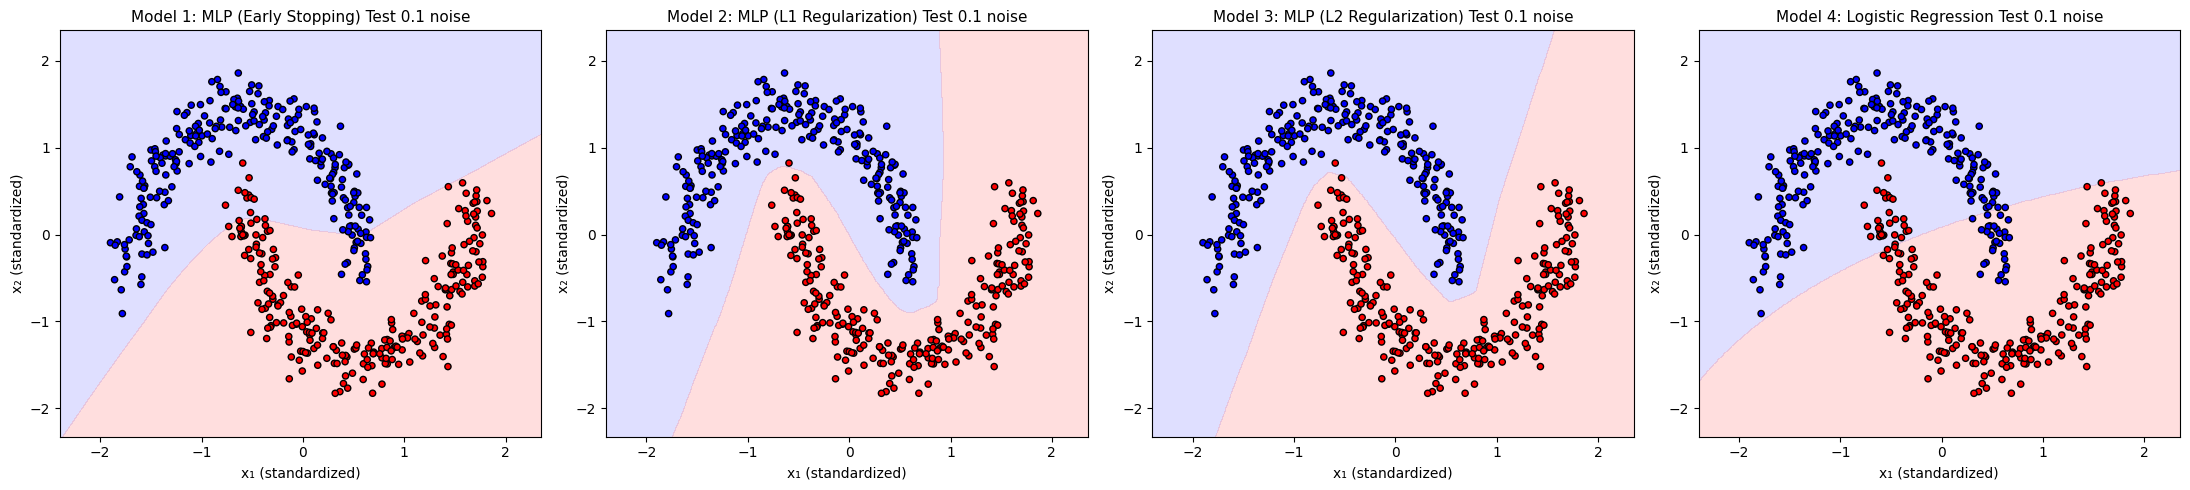

In [57]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

x_min, x_max = X_test_01_std[:, 0].min() - 0.5, X_test_01_std[:, 0].max() + 0.5
y_min, y_max = X_test_01_std[:, 1].min() - 0.5, X_test_01_std[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))
grid = np.c_[xx.ravel(), yy.ravel()]

# --- Model 1 predictions ---
Z1 = mlp_es.predict_proba(grid)[:, 1].reshape(xx.shape)

# --- Model 2 predictions (PyTorch L1 MLP) ---
probs2 = predict_probs(best_model, torch.from_numpy(grid.astype(np.float32)).to(device))
Z2 = (probs2 >= 0.5).astype(int).reshape(xx.shape)

# --- Model 3 predictions (L2 MLP) ---
Z3 = mlp.predict(grid).reshape(xx.shape)

# --- Model 4 predictions (Logistic Regression with polynomial features) ---
Z4 = logreg.predict(poly.transform(grid)).reshape(xx.shape)

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
titles = [
    "Model 1: MLP (Early Stopping) Test 0.1 noise",
    "Model 2: MLP (L1 Regularization) Test 0.1 noise",
    "Model 3: MLP (L2 Regularization) Test 0.1 noise",
    "Model 4: Logistic Regression Test 0.1 noise"
]

Z_list = [Z1, Z2, Z3, Z4]
for ax, Z, title in zip(axes, Z_list, titles):
    ax.contourf(xx, yy, Z, levels=[0, 0.5, 1], cmap='bwr', alpha=0.25)
    ax.scatter(X_test_01_std[:, 0], X_test_01_std[:, 1],
               c=y_test01, cmap='bwr', edgecolor='k', s=20)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("x₁ (standardized)")
    ax.set_ylabel("x₂ (standardized)")

plt.tight_layout()
plt.show()

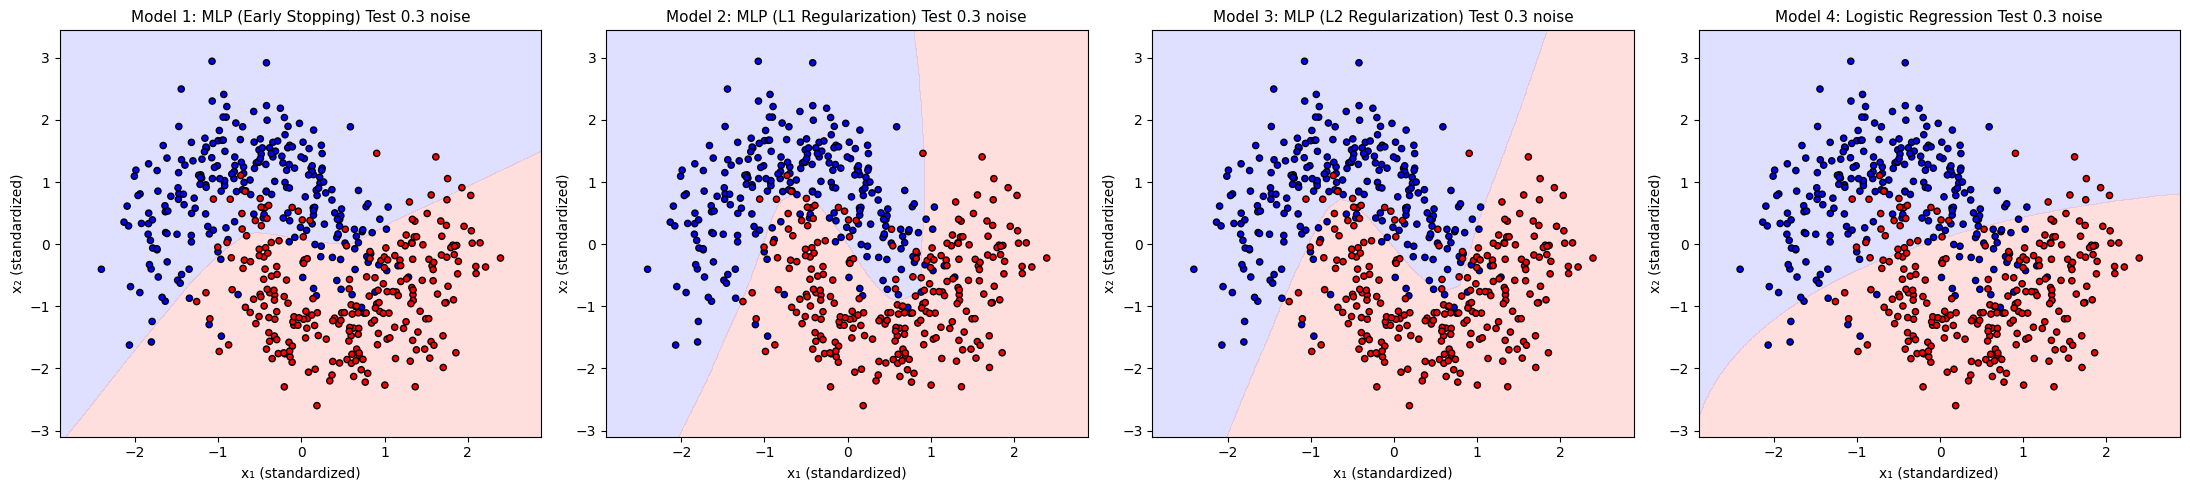

In [58]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

x_min, x_max = X_test_03_std[:, 0].min() - 0.5, X_test_03_std[:, 0].max() + 0.5
y_min, y_max = X_test_03_std[:, 1].min() - 0.5, X_test_03_std[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))
grid = np.c_[xx.ravel(), yy.ravel()]

# --- Model 1 predictions ---
Z1 = mlp_es.predict_proba(grid)[:, 1].reshape(xx.shape)

# --- Model 2 predictions (PyTorch L1 MLP) ---
probs2 = predict_probs(best_model, torch.from_numpy(grid.astype(np.float32)).to(device))
Z2 = (probs2 >= 0.5).astype(int).reshape(xx.shape)

# --- Model 3 predictions (L2 MLP) ---
Z3 = mlp.predict(grid).reshape(xx.shape)

# --- Model 4 predictions (Logistic Regression with polynomial features) ---
Z4 = logreg.predict(poly.transform(grid)).reshape(xx.shape)

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
titles = [
    "Model 1: MLP (Early Stopping) Test 0.3 noise",
    "Model 2: MLP (L1 Regularization) Test 0.3 noise",
    "Model 3: MLP (L2 Regularization) Test 0.3 noise",
    "Model 4: Logistic Regression Test 0.3 noise"
]

Z_list = [Z1, Z2, Z3, Z4]
for ax, Z, title in zip(axes, Z_list, titles):
    ax.contourf(xx, yy, Z, levels=[0, 0.5, 1], cmap='bwr', alpha=0.25)
    ax.scatter(X_test_03_std[:, 0], X_test_03_std[:, 1],
               c=y_test03, cmap='bwr', edgecolor='k', s=20)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("x₁ (standardized)")
    ax.set_ylabel("x₂ (standardized)")

plt.tight_layout()
plt.show()